In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [4]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 5/23 photon absorption

In [5]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

Fogi timing

In [6]:
header = "D:/K_sunada/result/CDY158/"
fogi_timing = "/2024-05-23/2024-05-23T015947_b1ce117f-75-sym_JPA_ab_fogi_timing"
fogi_timing1 = "/2024-05-23/2024-05-23T080104_2a6f5ed2-75-sym_JPA_ab_fogi_timing"

In [7]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_timing(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_delay = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        d = dd['fogi_delay']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_ref']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_delay.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_delay[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_delay, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

[71.28279309 67.80229581 77.67344422 72.63395361 74.31912082 73.33807966
 77.16498263 79.84366201 79.61201573 78.76473059 82.37359794 80.42816845
 78.57372441 82.23640035 84.40666413 85.18184907 84.26539369 87.39771836
 85.43283114 86.17862504 88.23913441 86.12767352 88.86828715 88.78383165
 91.31620976 88.73672288 90.03185169 90.75979122 91.61024595 90.46857631
 90.67263773 92.8265866  94.07368541 91.86754544 92.40253428 92.99967331
 93.90306954 92.15148715 92.58798819 94.15785864 92.05585322]


<Figure size 800x600 with 0 Axes>

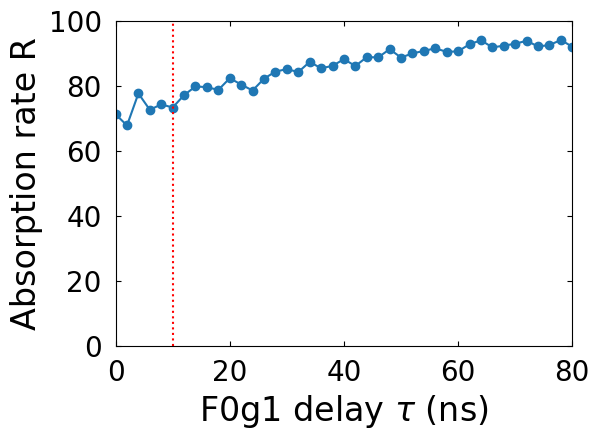

In [39]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing
num_of_ph_amp = 1
num_of_fogi_timing = 41
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(0, 80)
plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
# print(d[5][ph_amp][16], d[0][ph_amp][16])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

[93.46217008 93.41467697 92.18618547 92.32075514 92.26324047 92.44824017
 94.55884067 91.01478287 91.80148559 87.64901485 91.78139707 89.30574345
 92.66505765 93.19318301 92.20081086 87.73233272 89.7277744  88.49516465
 85.87189193 89.45612513 87.00254524]
94.55884067177891 92.0


<Figure size 800x600 with 0 Axes>

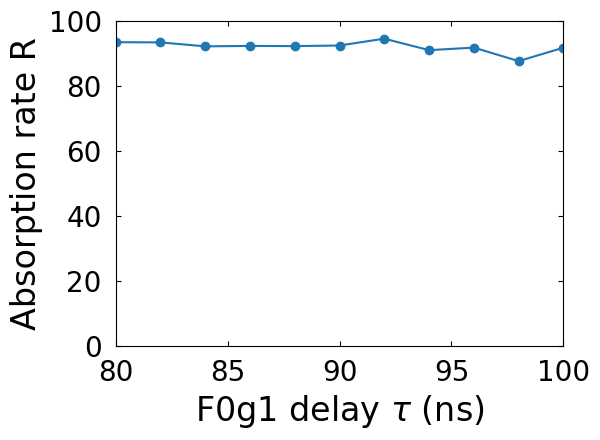

In [42]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing1
num_of_ph_amp = 1
num_of_fogi_timing = 21
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(80, 100)
plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
print(d[5][ph_amp][6], d[0][ph_amp][6])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

94.56


<Figure size 800x300 with 0 Axes>

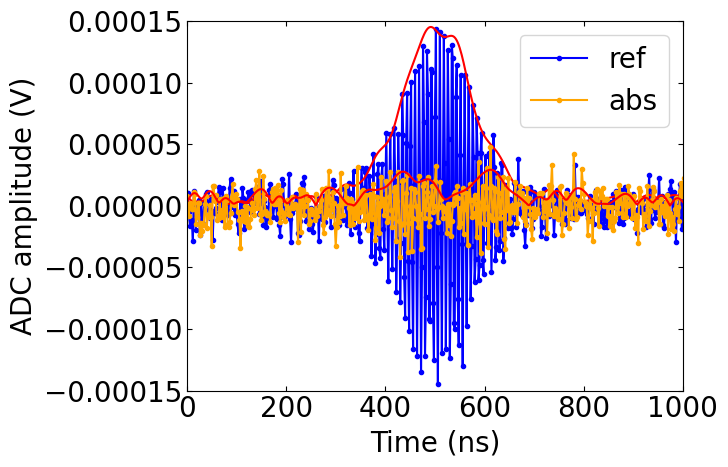

In [44]:
## waveform
ph_amp = 0
fogi_freq = 6
###############################################
data = fogi_timing1
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00015, 0.00015)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

# after phase correction

n_ava = 0.03

In [13]:
fogi_1027_pc = "/2024-05-23/2024-05-23T231150_664c0cd0-75-sym_JPA_ab_fogi_timing"
fogi_1029_pc = "/2024-05-23/2024-05-23T232441_31d68e0c-75-sym_JPA_ab_fogi_timing"
fogi_1031_pc = "/2024-05-23/2024-05-23T232617_6af4c799-75-sym_JPA_ab_fogi_timing"

83.55


<Figure size 800x300 with 0 Axes>

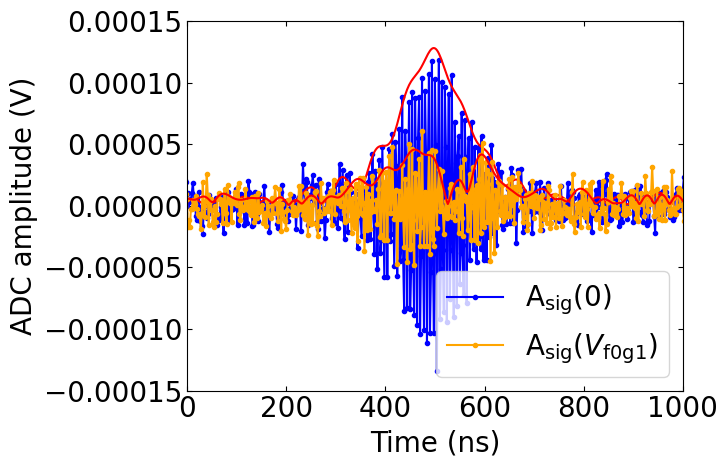

In [14]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1027_pc
num_of_ph_amp = 1
num_of_fogi_timing = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 150e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00015, 0.00015)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

91.69


<Figure size 800x300 with 0 Axes>

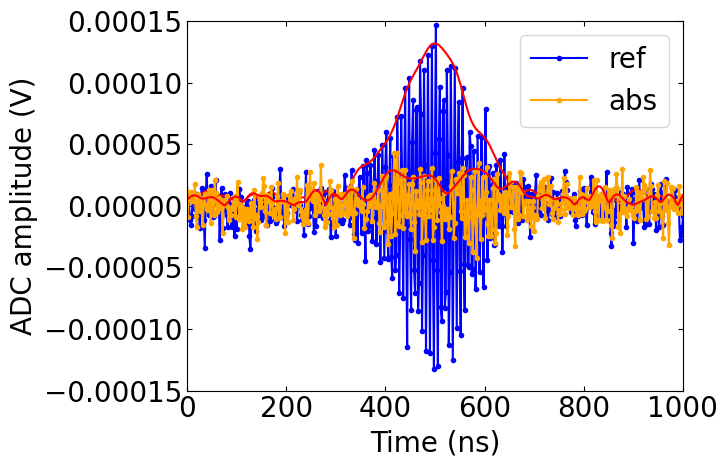

In [15]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1029_pc
num_of_ph_amp = 1
num_of_fogi_timing = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 130e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00015, 0.00015)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

93.08


<Figure size 800x300 with 0 Axes>

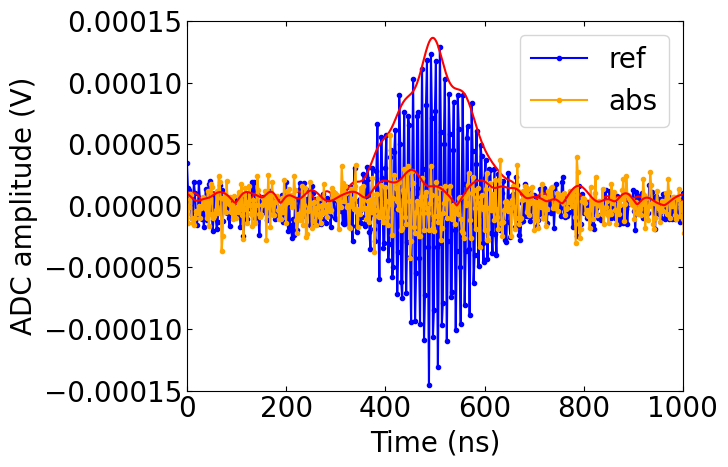

In [16]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1031_pc
num_of_ph_amp = 1
num_of_fogi_timing = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 110e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.00015, 0.00015)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

In [25]:
fogi_1028_pc003 = "/2024-05-23/2024-05-23T014003_f0085122-75-sym_JPA_ab_fogi_timing"
fogi_1030_pc003 = "/2024-05-23/2024-05-23T014609_ca9ee238-75-sym_JPA_ab_fogi_timing"
fogi_1032_pc003 = "/2024-05-23/2024-05-23T015036_69b94fe1-75-sym_JPA_ab_fogi_timing"

89.53


<Figure size 800x300 with 0 Axes>

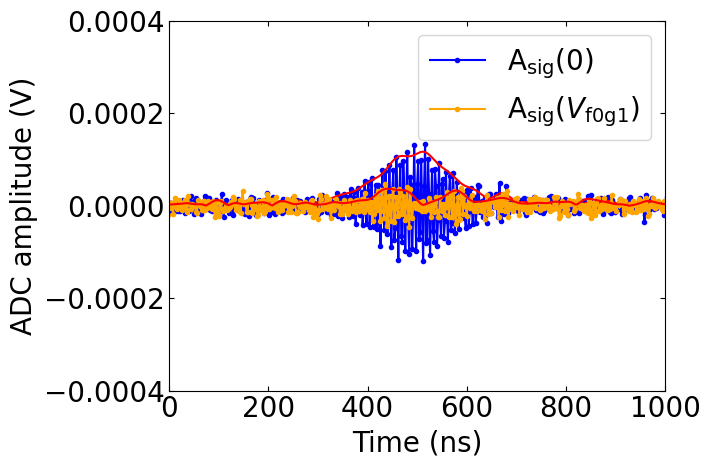

In [26]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1028_pc003
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 140e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0004, 0.0004)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

91.5


<Figure size 800x300 with 0 Axes>

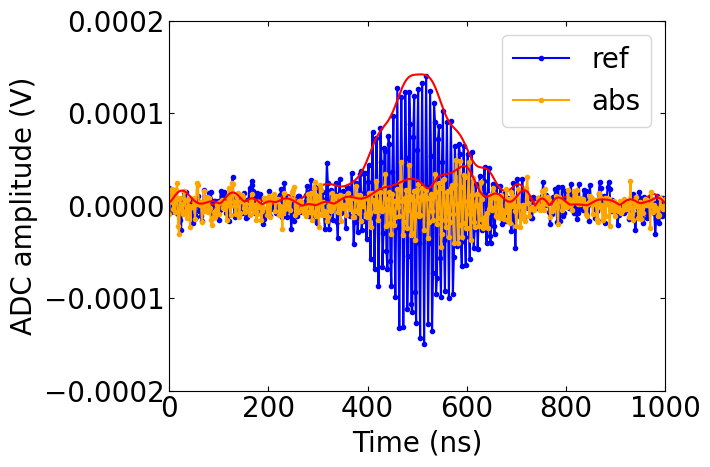

In [29]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1030_pc003
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 120e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0002, 0.0002)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()

65.65


<Figure size 800x300 with 0 Axes>

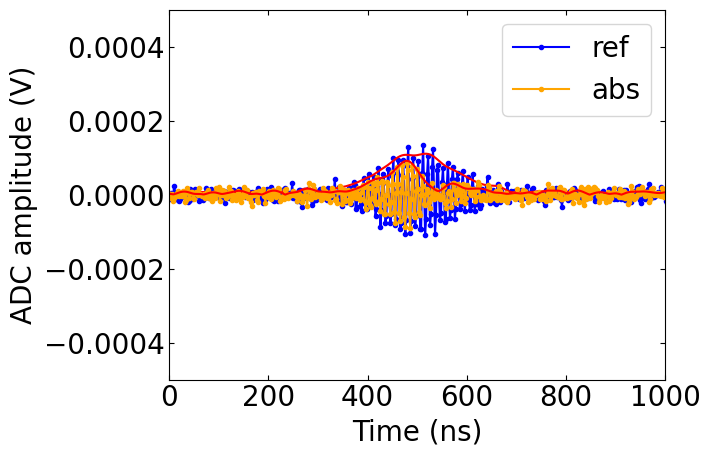

In [28]:
## waveform
ph_amp = 0
fogi_freq = 0
###############################################
data = fogi_1032_pc003
num_of_ph_amp = 1
num_of_fogi_freq = 1
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 100e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"ref")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"abs")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0005, 0.0005)
ax0.set_xlim(0, 1000)
plt.legend()
print(np.round(ab_rate, 2))
plt.show()